# Predicción de Abandono Temprano en Spotify — TP Minería de Datos (UTDT)

**Notebook de la Clase 1** (KNN). A partir de la Clase 2, cada clase queda en su propio notebook (copia del anterior + el contenido nuevo de esa clase), como registro de estudio — ver `tp_spotify_clase2_arboles.ipynb` y los que sigan. Este archivo se conserva tal cual quedó al cerrar la Clase 1.

## Clase 1 — Baseline con K-Nearest Neighbors (KNN)

Objetivo de esta sección: tener un pipeline end-to-end honesto (carga -> target -> EDA -> features -> split -> preprocesamiento -> modelo -> predicción -> submission), usando **exactamente** lo que vimos en la Clase 1: aprendizaje supervisado, clasificación binaria, el algoritmo de vecinos más cercanos (KNN), la noción de hiperparámetro (K), por qué hay que escalar/codificar variables para que la distancia euclídea tenga sentido, y por qué hay que medir performance en datos que el modelo no vio ("left out").

Esta sección ya va por su **segunda iteración**. Al baseline original (5 categóricas crudas, muestra de 20.000 filas, K elegido con holdout aleatorio) le sumamos, siempre dentro del temario de la Clase 1:

1. una carga de datos más cuidadosa con la memoria (el profesor insiste en que eso es parte del TP),
2. un EDA con figuras (que además pide el informe),
3. dos conjuntos de features categóricas adicionales, comparados honestamente contra el baseline,
4. un chequeo de cuánto cambia la estimación si el holdout respeta el tiempo (anticipo mínimo de la Clase 2), y
5. un modelo final entrenado sobre una muestra más grande (100.000 filas).

No buscamos que este modelo sea bueno. Buscamos que sea *correcto* y que deje instalada la lógica de validación que vamos a mejorar clase a clase.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

RANDOM_STATE = 42
DATA_DIR = "competition_data"

# Estilo único para todos los gráficos del notebook.
# Paleta categórica validada para daltonismo (orden fijo: azul, aqua, amarillo).
C_AZUL, C_AQUA, C_AMARILLO = "#2a78d6", "#1baf7a", "#eda100"
C_TEXTO, C_MUTED, C_GRILLA, C_EJES = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": C_GRILLA, "grid.linewidth": 0.8,
    "axes.edgecolor": C_EJES, "axes.labelcolor": C_TEXTO,
    "xtick.color": C_MUTED, "ytick.color": C_MUTED,
})

### Cargar los datos y construir el target

Dos decisiones en esta celda:

**Carga cuidadosa de memoria.** `train_data.txt` pesa ~211 MB y tiene 21 columnas, pero en esta sección usamos ~12. Si cargamos todo, pandas guarda en memoria cientos de miles de strings largos (nombres de canciones, álbumes, URIs de capítulos) que no vamos a tocar. El profesor marca explícitamente que trabajar los datos "de manera no ingenua" es parte del desafío del TP, así que le pasamos a `read_csv` la lista exacta de columnas (`usecols`) y fijamos el tipo de las columnas de URI (`dtype`) — esto último además elimina el `DtypeWarning` de tipos mixtos que aparecía en la primera versión del notebook.

**El target.** `train_data.txt` no trae columna `target`. Lo único que tenemos es `ms_played` (milisegundos reproducidos), disponible solo en train. La definición de "abandono temprano" no está escrita en ningún archivo del dataset — la dio el profesor de palabra en la Clase 1: reproducción de **menos de 30.000 ms (30 segundos)**, que es el umbral estándar de la industria del streaming (a partir de los 30 s se considera "escucha real" y se pagan regalías). Por eso: `target = 1` si `ms_played < 30000`, si no `0`. Una vez construido el target, `ms_played` queda descartado como feature: no existe en `test_data.txt` y además *es* el target disfrazado (data leakage).

In [2]:
USECOLS = [
    "obs_id", "ms_played", "ts", "platform_family", "conn_country",
    "master_metadata_album_artist_name",
    "spotify_track_uri", "spotify_episode_uri", "audiobook_uri",
    "shuffle", "offline", "incognito_mode",
]
DTYPES = {
    "spotify_track_uri": "string",
    "spotify_episode_uri": "string",
    "audiobook_uri": "string",
}

train_raw = pd.read_csv(f"{DATA_DIR}/train_data.txt", sep="\t", usecols=USECOLS, dtype=DTYPES)

train_raw["target"] = (train_raw["ms_played"] < 30000).astype(int)

print("Filas:", len(train_raw))
print("Proporción de abandono temprano (target=1):", train_raw["target"].mean().round(4))
train_raw[["obs_id", "ms_played", "target"]].head()

Filas: 911344
Proporción de abandono temprano (target=1): 0.278


,obs_id,ms_played,target
0,1,8956,1
1,2,202024,0
2,3,269480,0
3,4,24299,1
4,5,97877,0


### EDA: ¿qué variables categóricas separan a los que abandonan?

Antes de elegir features conviene mirar los datos (y el informe exige un EDA con al menos dos figuras). La pregunta guía es simple: para cada variable categórica candidata, **¿la tasa de abandono cambia entre categorías?** Si una variable muestra la misma tasa (~27.8%) en todas sus categorías, no le aporta nada a KNN; si la tasa se mueve mucho entre categorías, es candidata valiosa.

Además de las columnas crudas, acá derivamos tres variables nuevas — esto ya es *feature engineering*, y lo anotamos como tal para el informe:

- **`content_type`** (track / episode / audiobook): según cuál de las tres URIs está presente. En train las tres son mutuamente excluyentes, siempre hay exactamente una, y no existe ningún audiobook (907.211 tracks y 4.133 episodios).
- **`hora` y `dia_semana`**: extraídas de `ts`. Ojo con la lectura: `ts` está en **UTC** y la mayoría de las reproducciones son de Argentina (UTC−3), así que "las 3 UTC" son la medianoche local. Para KNN es solo una etiqueta categórica más (el corrimiento no cambia nada), pero para interpretar el gráfico sí importa.
- **`artista_top`**: el nombre de artista tiene decenas de miles de valores distintos — one-hot ingenuo no es razonable todavía. Compromiso simple compatible con la Clase 1: nos quedamos con los **50 artistas más frecuentes calculados solo sobre train** y agrupamos todo el resto (incluidos los episodios, que no tienen artista) en `"otros"`. Que la lista salga solo de train no es un capricho: cualquier decisión "aprendida" de los datos es parte del modelo, y el modelo no puede aprender nada del test.

In [3]:
# --- Tipo de contenido: cuál de las tres URIs está presente ---
train_raw["content_type"] = np.select(
    [train_raw["spotify_track_uri"].notna(),
     train_raw["spotify_episode_uri"].notna(),
     train_raw["audiobook_uri"].notna()],
    ["track", "episode", "audiobook"],
    default="desconocido",
)

# --- Hora y día de semana (en UTC) a partir de ts ---
ts_dt = pd.to_datetime(train_raw["ts"], utc=True, format="ISO8601")
train_raw["ts_dt"] = ts_dt
train_raw["hora"] = ts_dt.dt.hour
DIAS = ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"]
train_raw["dia_semana"] = ts_dt.dt.dayofweek.map(dict(enumerate(DIAS)))

# --- Artista agrupado: top 50 por frecuencia (aprendido SOLO de train), resto -> "otros" ---
col_artista = "master_metadata_album_artist_name"
TOP_ARTISTAS = train_raw[col_artista].value_counts().head(50).index
train_raw["artista_top"] = train_raw[col_artista].where(
    train_raw[col_artista].isin(TOP_ARTISTAS), "otros"
)  # los NaN (episodios sin artista) también caen en "otros"

def tasa_por(col):
    t = train_raw.groupby(col)["target"].agg(tasa="mean", cantidad="size")
    return t.sort_values("tasa", ascending=False)

print("Tasa de abandono global:", train_raw["target"].mean().round(4), "\n")
print(tasa_por("content_type").round(3), "\n")
print("Top 10 artistas más escuchados y su tasa de abandono:")
por_artista = train_raw[train_raw["artista_top"] != "otros"].groupby("artista_top")["target"].agg(tasa="mean", cantidad="size")
print(por_artista.sort_values("cantidad", ascending=False).head(10).round(3))

Tasa de abandono global: 0.278 

               tasa  cantidad
content_type                 
track         0.278    907211
episode       0.233      4133 

Top 10 artistas más escuchados y su tasa de abandono:
                                          tasa  cantidad
artista_top                                             
Patricio Rey y sus Redonditos de Ricota  0.353     10912
blink-182                                0.137     10557
The Rolling Stones                       0.174      8145
Red Hot Chili Peppers                    0.274      6816
Ramones                                  0.131      6235
Las Pelotas                              0.227      6119
Charly García                            0.327      6056
Fito Paez                                0.305      5908
Luis Pescetti                            0.218      5740
El Reino Infantil                        0.126      5712


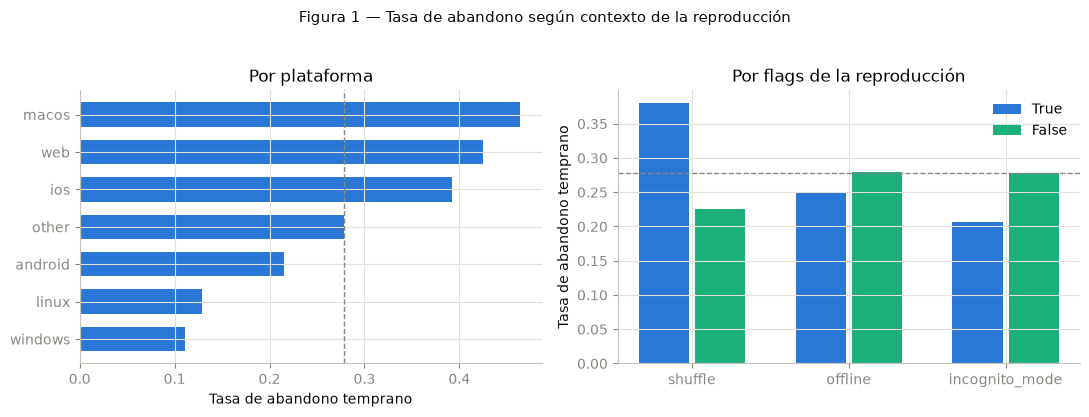

In [4]:
tasa_global = train_raw["target"].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# (a) por plataforma, ordenado por tasa
plat = tasa_por("platform_family")
axes[0].barh(plat.index[::-1], plat["tasa"][::-1], color=C_AZUL, height=0.65)
axes[0].axvline(tasa_global, color=C_MUTED, linestyle="--", linewidth=1)
axes[0].set_title("Por plataforma")
axes[0].set_xlabel("Tasa de abandono temprano")

# (b) por flags booleanos (True vs. False de cada uno)
flags = ["shuffle", "offline", "incognito_mode"]
tasas_true = [train_raw.loc[train_raw[f], "target"].mean() for f in flags]
tasas_false = [train_raw.loc[~train_raw[f], "target"].mean() for f in flags]
xpos = np.arange(len(flags))
axes[1].bar(xpos - 0.18, tasas_true, width=0.32, color=C_AZUL, label="True")
axes[1].bar(xpos + 0.18, tasas_false, width=0.32, color=C_AQUA, label="False")
axes[1].axhline(tasa_global, color=C_MUTED, linestyle="--", linewidth=1)
axes[1].set_xticks(xpos, flags)
axes[1].set_title("Por flags de la reproducción")
axes[1].set_ylabel("Tasa de abandono temprano")
axes[1].legend(frameon=False)

fig.suptitle("Figura 1 — Tasa de abandono según contexto de la reproducción",
             y=1.03, fontsize=11, color=C_TEXTO)
plt.tight_layout()
plt.show()

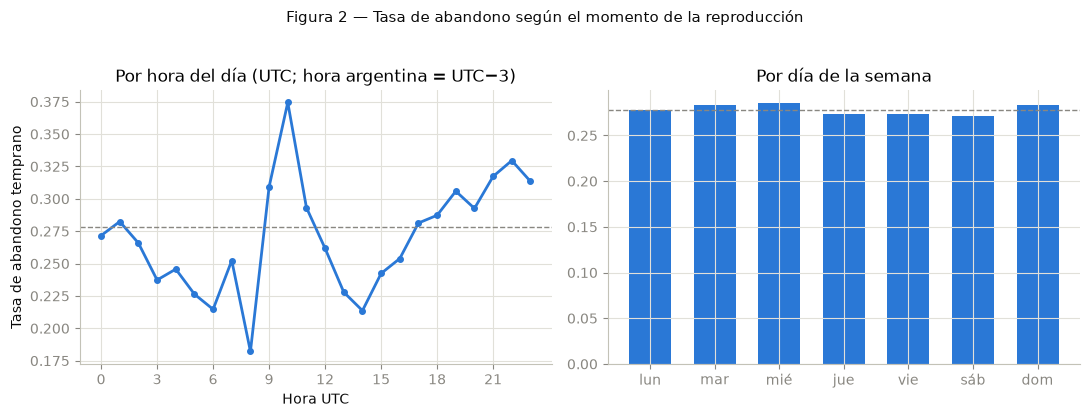

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

por_hora = train_raw.groupby("hora")["target"].mean()
axes[0].plot(por_hora.index, por_hora.values, color=C_AZUL, linewidth=2, marker="o", markersize=4)
axes[0].axhline(tasa_global, color=C_MUTED, linestyle="--", linewidth=1)
axes[0].set_xticks(range(0, 24, 3))
axes[0].set_title("Por hora del día (UTC; hora argentina = UTC−3)")
axes[0].set_xlabel("Hora UTC")
axes[0].set_ylabel("Tasa de abandono temprano")

por_dia = train_raw.groupby("dia_semana")["target"].mean().reindex(DIAS)
axes[1].bar(por_dia.index, por_dia.values, color=C_AZUL, width=0.65)
axes[1].axhline(tasa_global, color=C_MUTED, linestyle="--", linewidth=1)
axes[1].set_title("Por día de la semana")

fig.suptitle("Figura 2 — Tasa de abandono según el momento de la reproducción",
             y=1.03, fontsize=11, color=C_TEXTO)
plt.tight_layout()
plt.show()

**Cómo leer las figuras:** la línea punteada gris es la tasa global (27.8%); cuanto más se aparta una categoría de esa línea —en cualquier dirección— más información aporta esa variable para separar abandonos de no-abandonos. Esta lectura visual todavía no es un modelo: es la justificación empírica de qué features vale la pena probar. (Estas dos figuras, con esta lectura, son candidatas directas para el requisito de EDA del informe.)

### Tres conjuntos de features para comparar

En la primera iteración usamos un único conjunto de 5 categóricas crudas. Ahora definimos tres conjuntos **anidados** y dejamos que el holdout decida cuál conviene — comparar variantes contra datos no vistos es exactamente la lógica de la Clase 1, solo que aplicada a las features en lugar del K:

- **Conjunto A (base):** `platform_family`, `conn_country`, `shuffle`, `offline`, `incognito_mode` — el baseline original.
- **Conjunto B (A + momento):** suma `hora` y `dia_semana`. Es la señal temporal *cíclica* (dentro del día y de la semana), no la fecha absoluta. No usamos año/mes deliberadamente: como el test es todo posterior al train, una categoría tipo "2024" invitaría al modelo a apoyarse en algo que no se traslada al futuro.
- **Conjunto C (B + contenido):** suma `content_type` y `artista_top`.

Siguen afuera, con el mismo razonamiento de la primera iteración: `user_id` (identificador, no una característica generalizable), los nombres/URIs crudos (cardinalidad altísima; la consigna sugiere técnicas tipo *bin-counting* que veremos más adelante), `offline_timestamp`, y todo `spotify_api_data`.

In [6]:
FEATURES_BASE = ["platform_family", "conn_country", "shuffle", "offline", "incognito_mode"]
FEATURE_SETS = {
    "A: base": FEATURES_BASE,
    "B: A + hora/día": FEATURES_BASE + ["hora", "dia_semana"],
    "C: B + contenido": FEATURES_BASE + ["hora", "dia_semana", "content_type", "artista_top"],
}
TODAS_LAS_FEATURES = FEATURE_SETS["C: B + contenido"]

for col in TODAS_LAS_FEATURES:
    print(f"{col}: {train_raw[col].nunique()} valores distintos, {train_raw[col].isna().mean():.2%} missing")

platform_family: 7 valores distintos, 0.00% missing
conn_country: 43 valores distintos, 0.00% missing
shuffle: 2 valores distintos, 0.00% missing
offline: 2 valores distintos, 0.00% missing
incognito_mode: 2 valores distintos, 0.00% missing
hora: 24 valores distintos, 0.00% missing
dia_semana: 7 valores distintos, 0.00% missing
content_type: 2 valores distintos, 0.00% missing
artista_top: 51 valores distintos, 0.00% missing


### Por qué subsampleamos para KNN (y para nada más)

`train_data.txt` tiene ~911.000 filas. En la Clase 1 vimos que el punto más débil de KNN es justo este: para predecir una sola observación nueva, el algoritmo tiene que calcular la distancia contra **todas** las observaciones de entrenamiento — no aprende una fórmula compacta como una regresión. Con cientos de miles de filas de entrenamiento y decenas de miles de observaciones a predecir, eso son miles de millones de cálculos de distancia. Es manejable pero lento, y no tiene sentido pagar ese costo mientras todavía estamos con un modelo de prueba.

Por eso, **solo para este baseline con KNN**, tomamos una muestra al azar (estratificada por `target`, para no alterar el balance de clases) del conjunto de entrenamiento. Esto es una decisión puntual de esta técnica — cuando en clases siguientes usemos árboles u otros modelos que no dependen de comparar contra todo el training set, no va a hacer falta subsamplear de esta manera.

In [7]:
SAMPLE_SIZE = 20000

sample, _ = train_test_split(
    train_raw,
    train_size=SAMPLE_SIZE,
    stratify=train_raw["target"],
    random_state=RANDOM_STATE,
)

# X lleva TODAS las features candidatas (cada pipeline elige después su subconjunto).
# Conservamos también el sample entero: ts_dt hace falta para el chequeo temporal de más adelante.
X = sample[TODAS_LAS_FEATURES].fillna("missing").astype(str)
y = sample["target"]

print("Muestra usada para KNN:", X.shape)
print("Proporción de target=1 en la muestra:", y.mean().round(4))

Muestra usada para KNN: (20000, 9)
Proporción de target=1 en la muestra: 0.278


### Split entrenamiento / "left out"

Igual que en la Clase 1: separamos al azar una parte de los datos que el modelo va a poder usar para aprender (`X_train`/`y_train`) de otra parte que reservamos para simular "datos que todavía no conocemos" (`X_holdout`/`y_holdout`, el "left out" del profesor). Entrenamos únicamente con el primer grupo y medimos la performance real en el segundo.

**Importante:** este split es al azar, sin tener en cuenta el tiempo, mientras que la competencia separa train/test por fecha (`test_data.txt` es todo posterior a 2024-09-01). Un split al azar puede darnos una estimación optimista de cómo nos va a ir en Kaggle. Más abajo en esta misma sección hay un chequeo explícito de cuánto cambia la estimación cuando el holdout respeta el tiempo; el esquema de validación formal llega con la Clase 2.

In [8]:
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, " Holdout:", X_holdout.shape)

Train: (15000, 9)  Holdout: (5000, 9)


### Preprocesamiento: one-hot encoding + escalado, dentro de un Pipeline

Todas nuestras features son categóricas (incluso los booleanos los tratamos como tal), así que:

1. **One-hot encoding**: la distancia euclídea no tiene sentido entre categorías (`"AR" - "US"` al cuadrado no significa nada). Convertimos cada categoría en columnas binarias 0/1, tal como se vio en clase. Usamos `handle_unknown="ignore"` porque en el conjunto de test real puede aparecer algún país que no vimos en nuestra muestra de entrenamiento.
2. **Escalado (z-score)**: la Clase 1 mostró que la distancia euclídea queda dominada por las variables de mayor varianza, y que estandarizar (`StandardScaler`) puede cambiar mucho el resultado — en el ejemplo del dataset de spam, pasar de no escalar a escalar mejoró la performance más que ajustar bien el K. Ojo: la clase también fue clara en que escalar *no* es una receta que siempre mejora las cosas — acá lo hacemos porque es la práctica estándar con KNN y porque, al ser todas las columnas dummies 0/1 post one-hot, escalar no distorsiona nada raro.

Todo esto se arma en un único `Pipeline` de scikit-learn (`ColumnTransformer` + `StandardScaler` + `KNeighborsClassifier`), igual que el `make_pipeline` que se mostró en la clase.

In [9]:
def build_knn_pipeline(k, features):
    preprocessor = ColumnTransformer(
        transformers=[
            ("onehot", OneHotEncoder(handle_unknown="ignore"), features),
        ],
        remainder="drop",  # las columnas de X que no estén en `features` se descartan
    )
    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("scaler", StandardScaler(with_mean=False)),  # el output de OneHotEncoder es sparse
            ("knn", KNeighborsClassifier(n_neighbors=k)),
        ]
    )

Un detalle técnico que vale explicar: `OneHotEncoder` devuelve una matriz *sparse* (la mayoría de las celdas son 0, como vimos en el ejemplo de red/green/blue de la clase). Si le restáramos la media a cada columna (el z-score "completo"), esa matriz dejaría de tener ceros y se volvería densa — con miles de columnas de países/plataformas eso puede ser mucha memoria de golpe. Por eso usamos `with_mean=False`: solo dividimos por el desvío estándar, sin centrar en 0. Sigue cumpliendo el objetivo de la Clase 1 (que ninguna columna domine la distancia solo por su escala), pero es más eficiente en memoria.

### Comparar los tres conjuntos de features (mismo split, misma grilla de K)

Para que la comparación sea justa, los tres conjuntos se evalúan con **el mismo split** train/holdout y **la misma grilla de K**. Medimos solo el AUC de holdout (lo único que decide) y con una grilla reducida de 5 valores — el barrido fino de K lo hacemos después, únicamente con el conjunto ganador, para no pagar el costo computacional de KNN 27 veces.

Un detalle: como los conjuntos están anidados (A ⊂ B ⊂ C), si el AUC *empeora* al agregar variables no es un error — es la maldición de la dimensionalidad de la Clase 1 en acción: cada columna nueva que no aporta señal agrega distancia "ruido" que puede tapar a las columnas que sí informan.

A: base            | K=25: 0.6664 | K=51: 0.6743 | K=101: 0.6773 | K=201: 0.6889 | K=501: 0.6843
B: A + hora/día    | K=25: 0.6788 | K=51: 0.6791 | K=101: 0.6815 | K=201: 0.6890 | K=501: 0.6596
C: B + contenido   | K=25: 0.6850 | K=51: 0.6761 | K=101: 0.6903 | K=201: 0.6888 | K=501: 0.6720


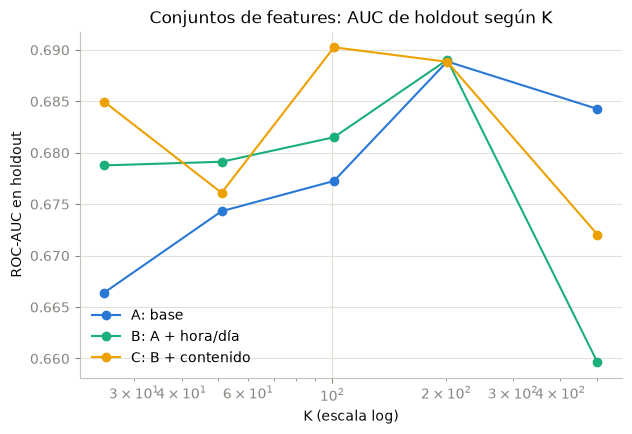

Conjunto ganador según holdout: C: B + contenido


In [10]:
k_grid = [25, 51, 101, 201, 501]
resultados_sets = {}

for nombre, feats in FEATURE_SETS.items():
    aucs = []
    for k in k_grid:
        pipe = build_knn_pipeline(k, feats)
        pipe.fit(X_train, y_train)
        aucs.append(roc_auc_score(y_holdout, pipe.predict_proba(X_holdout)[:, 1]))
    resultados_sets[nombre] = aucs
    print(f"{nombre:<18} | " + " | ".join(f"K={k}: {a:.4f}" for k, a in zip(k_grid, aucs)))

plt.figure(figsize=(7, 4.5))
for (nombre, aucs), color in zip(resultados_sets.items(), [C_AZUL, C_AQUA, C_AMARILLO]):
    plt.plot(k_grid, aucs, marker="o", color=color, label=nombre)
plt.xscale("log")
plt.xlabel("K (escala log)")
plt.ylabel("ROC-AUC en holdout")
plt.title("Conjuntos de features: AUC de holdout según K")
plt.legend(frameon=False)
plt.show()

mejor_nombre = max(resultados_sets, key=lambda n: max(resultados_sets[n]))
mejor_feats = FEATURE_SETS[mejor_nombre]
print("Conjunto ganador según holdout:", mejor_nombre)

### Barrido fino de K — solo para el conjunto ganador

Replicamos el experimento de la clase sobre el conjunto de features que ganó la comparación: probamos varios valores de K, y para cada uno medimos el ROC-AUC tanto en `train` (para diagnóstico) como en `holdout` (lo que realmente importa). La expectativa, según lo visto:

- **K chico** (ej. 1): el modelo es muy flexible, se ajusta casi perfecto al training pero puede no generalizar → señal de **overfitting** si el holdout queda mucho peor que train.
- **K grande** (cercano al tamaño de la muestra): el modelo se vuelve rígido y tiende a predecir la proporción general de la clase (el *prior*) → **underfitting**.
- En algún punto intermedio debería haber un "sweet spot".

(Nota honesta de la primera iteración, que sigue valiendo: con features categóricas de baja cardinalidad hay muchísimas filas con el perfil idéntico de features, así que K=1 no puede "memorizar" perfecto — la brecha train/holdout va a ser chica en todos los K. El patrón de U invertida en holdout debería verse igual.)

In [11]:
k_values = [1, 5, 15, 25, 51, 101, 201, 501, 1001]
train_scores = []
holdout_scores = []

for k in k_values:
    pipe = build_knn_pipeline(k, mejor_feats)
    pipe.fit(X_train, y_train)

    train_auc = roc_auc_score(y_train, pipe.predict_proba(X_train)[:, 1])
    holdout_auc = roc_auc_score(y_holdout, pipe.predict_proba(X_holdout)[:, 1])

    train_scores.append(train_auc)
    holdout_scores.append(holdout_auc)
    print(f"K={k:>5} | ROC-AUC train={train_auc:.4f} | ROC-AUC holdout={holdout_auc:.4f}")

K=    1 | ROC-AUC train=0.6926 | ROC-AUC holdout=0.5694
K=    5 | ROC-AUC train=0.7620 | ROC-AUC holdout=0.6577
K=   15 | ROC-AUC train=0.7528 | ROC-AUC holdout=0.6811
K=   25 | ROC-AUC train=0.7345 | ROC-AUC holdout=0.6850
K=   51 | ROC-AUC train=0.7060 | ROC-AUC holdout=0.6761
K=  101 | ROC-AUC train=0.7096 | ROC-AUC holdout=0.6903
K=  201 | ROC-AUC train=0.6973 | ROC-AUC holdout=0.6888
K=  501 | ROC-AUC train=0.6754 | ROC-AUC holdout=0.6720
K= 1001 | ROC-AUC train=0.6779 | ROC-AUC holdout=0.6778


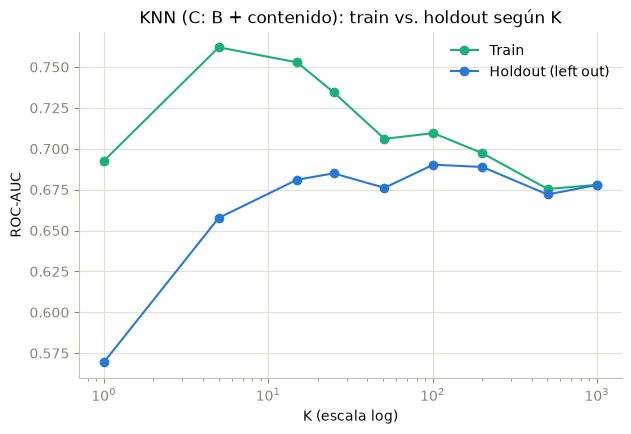

Mejor K según holdout: 101 -> ROC-AUC holdout: 0.6903


In [12]:
plt.figure(figsize=(7, 4.5))
plt.plot(k_values, train_scores, marker="o", color=C_AQUA, label="Train")
plt.plot(k_values, holdout_scores, marker="o", color=C_AZUL, label="Holdout (left out)")
plt.xscale("log")
plt.xlabel("K (escala log)")
plt.ylabel("ROC-AUC")
plt.title(f"KNN ({mejor_nombre}): train vs. holdout según K")
plt.legend(frameon=False)
plt.show()

best_k = k_values[int(np.argmax(holdout_scores))]
print("Mejor K según holdout:", best_k, "-> ROC-AUC holdout:", round(max(holdout_scores), 4))

**Para interpretar el gráfico:** si la curva de holdout sube, llega a un pico y vuelve a bajar, ese es el patrón overfitting→underfitting de la clase. Nos quedamos con el K que maximiza el ROC-AUC en **holdout** — no en train, porque el holdout es nuestra mejor estimación disponible de "datos que el modelo no conoce", que es lo único que nos interesa (en Kaggle nos evalúan sobre datos que jamás vimos).

### Chequeo de honestidad: ¿y si el holdout respetara el tiempo?

Nuestro split es al azar, pero Kaggle nos evalúa sobre **el futuro**: test = septiembre a diciembre de 2024, train = todo lo anterior. Un holdout al azar mezcla épocas — el modelo "ve" reproducciones de la misma semana que las que después le pedimos predecir, algo que en la competencia jamás va a pasar. Eso puede inflar nuestra estimación.

Para dimensionar cuánto, repetimos el barrido de K con un único cambio: ordenamos la muestra por fecha, entrenamos con el **75% más viejo** y validamos con el **25% más nuevo**. Todo lo demás queda idéntico. La teoría formal de esquemas de validación llega en la Clase 2 — esto es solo la versión mínima del experimento, hecha con herramientas que ya tenemos, y nos deja el número contra el cual comparar el leaderboard público (comparación que el informe pide explícitamente).

El holdout temporal arranca en: 2022-08-09
K=    1 | ROC-AUC holdout temporal=0.5310
K=    5 | ROC-AUC holdout temporal=0.5714
K=   15 | ROC-AUC holdout temporal=0.6201
K=   25 | ROC-AUC holdout temporal=0.6175
K=   51 | ROC-AUC holdout temporal=0.6267
K=  101 | ROC-AUC holdout temporal=0.6401
K=  201 | ROC-AUC holdout temporal=0.6405
K=  501 | ROC-AUC holdout temporal=0.6429
K= 1001 | ROC-AUC holdout temporal=0.6477


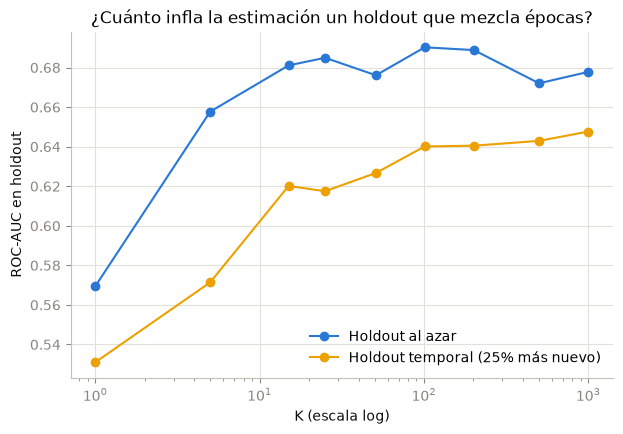

Mejor AUC con holdout al azar:  0.6903
Mejor AUC con holdout temporal: 0.6477


In [13]:
sample_ord = sample.sort_values("ts_dt")
X_ord = sample_ord[TODAS_LAS_FEATURES].fillna("missing").astype(str)
y_ord = sample_ord["target"]

n_corte = int(len(sample_ord) * 0.75)
X_train_t, X_holdout_t = X_ord.iloc[:n_corte], X_ord.iloc[n_corte:]
y_train_t, y_holdout_t = y_ord.iloc[:n_corte], y_ord.iloc[n_corte:]
print("El holdout temporal arranca en:", sample_ord["ts_dt"].iloc[n_corte].date())

holdout_scores_temporal = []
for k in k_values:
    pipe = build_knn_pipeline(k, mejor_feats)
    pipe.fit(X_train_t, y_train_t)
    auc = roc_auc_score(y_holdout_t, pipe.predict_proba(X_holdout_t)[:, 1])
    holdout_scores_temporal.append(auc)
    print(f"K={k:>5} | ROC-AUC holdout temporal={auc:.4f}")

plt.figure(figsize=(7, 4.5))
plt.plot(k_values, holdout_scores, marker="o", color=C_AZUL, label="Holdout al azar")
plt.plot(k_values, holdout_scores_temporal, marker="o", color=C_AMARILLO, label="Holdout temporal (25% más nuevo)")
plt.xscale("log")
plt.xlabel("K (escala log)")
plt.ylabel("ROC-AUC en holdout")
plt.title("¿Cuánto infla la estimación un holdout que mezcla épocas?")
plt.legend(frameon=False)
plt.show()

print(f"Mejor AUC con holdout al azar:  {max(holdout_scores):.4f}")
print(f"Mejor AUC con holdout temporal: {max(holdout_scores_temporal):.4f}")

### Modelo final: muestra más grande, K revalidado, submission

Tres decisiones para el modelo que va a Kaggle, cada una con su porqué:

1. **Conjunto de features:** el ganador de la comparación.
2. **Muestra de 100.000 filas** (5× la de exploración). El costo de KNN crece multiplicativamente con train × predicciones, así que no podíamos usar este tamaño para *iterar* — pero acá ya no iteramos: es una validación corta de K y una única predicción final. Pagamos más cómputo exactamente donde más rinde.
3. **K revalidado sobre la muestra grande, con holdout temporal.** El K óptimo no viaja automáticamente cuando cambia el tamaño del training set: con 5× más filas, cada "perfil" de features tiene ~5× más copias, y el mismo K cubre un vecindario proporcionalmente más chico. Probamos tres candidatos (el K ganador del barrido, uno intermedio y uno escalado ~5×) y elegimos con holdout temporal, que es el que mejor imita a Kaggle.

Al final reentrenamos con la muestra completa de 100.000 (la validación ya cumplió su rol — mismo argumento que antes: no regalamos datos) y generamos `submission_clase1_knn_v2.csv`. Dejamos el `submission_clase1_knn.csv` original intacto: con 3 submits por día podemos mandar ambos y comparar en el leaderboard público cuánto aportó cada mejora.

In [14]:
SAMPLE_FINAL = 100_000

sample_final, _ = train_test_split(
    train_raw,
    train_size=SAMPLE_FINAL,
    stratify=train_raw["target"],
    random_state=RANDOM_STATE,
)
sample_final = sample_final.sort_values("ts_dt")
X_final = sample_final[TODAS_LAS_FEATURES].fillna("missing").astype(str)
y_final = sample_final["target"]

# --- Revalidar K sobre la muestra grande: 75% más viejo entrena, 25% más nuevo valida ---
n_corte = int(len(sample_final) * 0.75)
candidatos_k = [best_k, 701, 1501]

mejor_k_final, mejor_auc_final = None, -1.0
for k in candidatos_k:
    pipe = build_knn_pipeline(k, mejor_feats)
    pipe.fit(X_final.iloc[:n_corte], y_final.iloc[:n_corte])
    auc = roc_auc_score(y_final.iloc[n_corte:], pipe.predict_proba(X_final.iloc[n_corte:])[:, 1])
    print(f"K={k:>5} | ROC-AUC holdout temporal (muestra de 100k) = {auc:.4f}")
    if auc > mejor_auc_final:
        mejor_k_final, mejor_auc_final = k, auc

print("\nK elegido para el modelo final:", mejor_k_final)

# --- Reentrenar con TODA la muestra final y predecir el test de la competencia ---
final_pipeline = build_knn_pipeline(mejor_k_final, mejor_feats)
final_pipeline.fit(X_final, y_final)

test_raw = pd.read_csv(
    f"{DATA_DIR}/test_data.txt", sep="\t",
    usecols=[c for c in USECOLS if c != "ms_played"], dtype=DTYPES,
)

# Mismas derivaciones que en train (con la lista TOP_ARTISTAS aprendida de train)
test_raw["content_type"] = np.select(
    [test_raw["spotify_track_uri"].notna(),
     test_raw["spotify_episode_uri"].notna(),
     test_raw["audiobook_uri"].notna()],
    ["track", "episode", "audiobook"],
    default="desconocido",
)
ts_test = pd.to_datetime(test_raw["ts"], utc=True, format="ISO8601")
test_raw["hora"] = ts_test.dt.hour
test_raw["dia_semana"] = ts_test.dt.dayofweek.map(dict(enumerate(DIAS)))
test_raw["artista_top"] = test_raw[col_artista].where(
    test_raw[col_artista].isin(TOP_ARTISTAS), "otros"
)

X_test = test_raw[TODAS_LAS_FEATURES].fillna("missing").astype(str)
test_pred_proba = final_pipeline.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    "obs_id": test_raw["obs_id"],
    "target": test_pred_proba,
})
submission.to_csv("submission_clase1_knn_v2.csv", index=False)
print("\nGuardado submission_clase1_knn_v2.csv —", len(submission), "filas")
submission.head()

K=  101 | ROC-AUC holdout temporal (muestra de 100k) = 0.6320
K=  701 | ROC-AUC holdout temporal (muestra de 100k) = 0.6396
K= 1501 | ROC-AUC holdout temporal (muestra de 100k) = 0.6337

K elegido para el modelo final: 701

Guardado submission_clase1_knn_v2.csv — 51570 filas


,obs_id,target
0,911345,0.255350
1,911346,0.218260
2,911347,0.134094
3,911348,0.134094
4,911349,0.134094


### Notas honestas para el informe (borrador, ir completando)

- **Qué probamos (Clase 1, segunda iteración):** KNN con one-hot + escalado. EDA con dos figuras sobre el train completo; tres conjuntos de features anidados (base / + hora y día de semana / + tipo de contenido y artista top-50) comparados con el mismo split y la misma grilla de K; barrido fino de K para el conjunto ganador; chequeo de holdout temporal vs. aleatorio; modelo final sobre muestra de 100.000 filas con K revalidado temporalmente. Los números concretos quedan impresos en las celdas de arriba.
- **Feature engineering hecho y justificado:** `content_type` (según cuál URI está presente), `hora` y `dia_semana` (desde `ts`, en UTC), `artista_top` (top 50 por frecuencia aprendido solo de train, resto agrupado en "otros" para evitar tanto la explosión de cardinalidad como el leakage).
- **Por qué muestras y no todo el dataset:** el costo de predicción de KNN escala con (filas de train) × (filas a predecir) — no aprende una fórmula compacta. 20.000 filas para iterar rápido, 100.000 solo para el modelo final, donde el cómputo se paga una única vez.
- **Validación:** el holdout aleatorio tiende a sobrestimar respecto del temporal (ver la figura de comparación) porque Kaggle evalúa sobre el futuro. El esquema formal de validación queda pendiente para la Clase 2 — acá ya quedó la evidencia empírica de por qué hace falta.
- **Submissions:** `submission_clase1_knn.csv` (v1: baseline de la primera iteración) y `submission_clase1_knn_v2.csv` (v2: más features + muestra grande + K revalidado). Mandar ambos al leaderboard público y anotar acá los scores para comparar contra nuestras estimaciones internas.
- **Próximos pasos naturales** (no los hacemos todavía): esquema de validación formal (Clase 2), variables de alta cardinalidad con *bin-counting*, metadata de `spotify_api_data`, y otros algoritmos — el profesor adelantó que los basados en árboles suelen ser los más competitivos en tabular.